In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())
from keras.models import Model
from keras.optimizers import Adam
from keras.layers import Convolution2D, MaxPooling2D, Dropout, Flatten, Dense, Input, concatenate
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import pandas as pd
import random
import ntpath

torch


In [2]:
data_dir = 'sim_data'
columns = ['rgb', 'mask', 'steering']
data = pd.read_csv(os.path.join(data_dir, 'driving_log.csv'), names=columns)
pd.set_option('display.max_colwidth', None)
data.head()

,rgb,mask,steering
0,rgb,mask,steering
1,driving_model/sim_data/RGB\00000.png,driving_model/sim_data/masks\00000.png,0.0
2,driving_model/sim_data/RGB\00001.png,driving_model/sim_data/masks\00001.png,0.0
3,driving_model/sim_data/RGB\00002.png,driving_model/sim_data/masks\00002.png,0.0
4,driving_model/sim_data/RGB\00003.png,driving_model/sim_data/masks\00003.png,0.0


In [3]:
def path_leaf(path):
    head, tail = ntpath.split(path)
    return tail
data['rgb'] = data['rgb'].apply(path_leaf)
data['mask'] = data['mask'].apply(path_leaf)

data.head()

,rgb,mask,steering
0,rgb,mask,steering
1,00000.png,00000.png,0.0
2,00001.png,00001.png,0.0
3,00002.png,00002.png,0.0
4,00003.png,00003.png,0.0


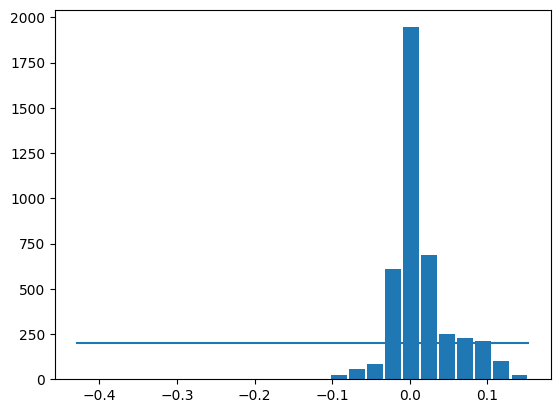

In [4]:
data['steering'] = pd.to_numeric(data['steering'], errors='coerce')
data = data.dropna(subset=['steering'])
num_bins = 25
samples_per_bin = 200
hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
plt.bar(center, hist, width=0.02)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

length of data 4231
removed 2732
remaining data 1499


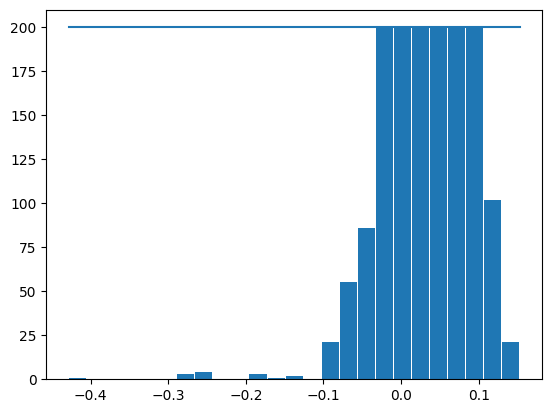

In [5]:
print(f"length of data {len(data)}")
remove_list = []

for j in range(num_bins):
    list_ = []
    for i in range(len(data['steering'])):
        if data['steering'].iloc[i] >= bins[j] and data['steering'].iloc[i] <= bins[j+1]:
            list_.append(i)
    list_ = shuffle(list_)
    list_ = list_[samples_per_bin:]
    remove_list.extend(list_)

print(f'removed {len(remove_list)}')
data.drop(data.index[remove_list], inplace=True)
print(f'remaining data {len(data)}')

hist, _ = np.histogram(data['steering'], (num_bins))
plt.bar(center, hist, width=0.022)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

In [6]:
print(data.iloc[1])
def load_img_mask_steering(rgb_dir, mask_dir, df):
    rgb_path = []
    mask_path = []
    steering = []
    for i in range(len(data)):
        indexed_data = data.iloc[i]
        rgb = indexed_data[0]
        mask = indexed_data[1]
        rgb_path.append(os.path.join(rgb_dir, rgb.strip()))
        mask_path.append(os.path.join(mask_dir, mask.strip()))
        steering.append(float(indexed_data[2]))
    rgb_paths = np.asarray(rgb_path)
    maks_paths = np.asarray(mask_path)
    steerings = np.asarray(steering)

    return rgb_paths, maks_paths, steerings

rgb_paths, mask_paths, steerings = load_img_mask_steering(data_dir + '/RGB', data_dir + '/masks', data)

rgb         00016.png
mask        00016.png
steering     0.055545
Name: 17, dtype: object


C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_15680\185578654.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rgb = indexed_data[0]
C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_15680\185578654.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mask = indexed_data[1]
C:\Users\Kanumuri\AppData\Local\Temp\ipykernel_15680\185578654.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  steering.append(float(indexed_data[2]))


In [7]:
rgb_train, rgb_valid, mask_train, mask_valid, steer_train, steer_valid = train_test_split(rgb_paths, mask_paths, steerings, test_size=0.2, random_state=6)
print(f"Training Samples: {len(rgb_train)}\nValid Samples: {len(rgb_valid)}")

Training Samples: 1199
Valid Samples: 300


Text(0.5, 1.0, 'Validation Set')

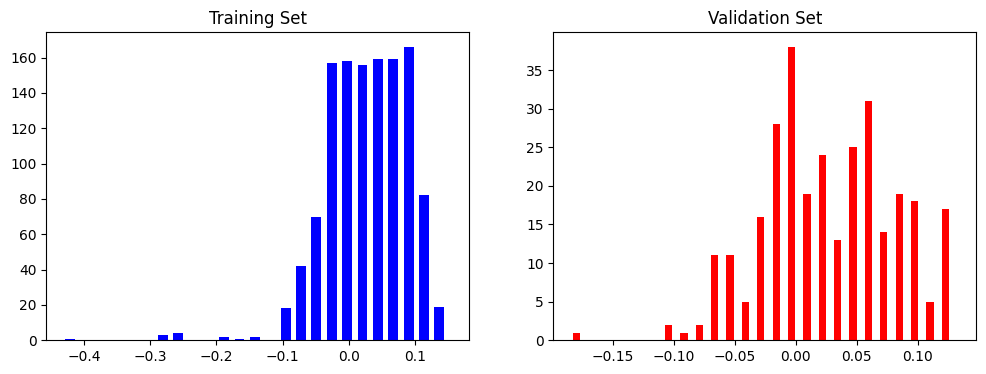

In [8]:
fix, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(steer_train, bins=num_bins, width=0.015, color='blue')
axes[0].set_title('Training Set')
axes[1].hist(steer_valid, bins=num_bins, width=0.006, color='red')
axes[1].set_title('Validation Set')

In [9]:
def zoom(img, mask):
    zoom = A.Compose(
        [A.Affine(scale=(1.0, 1.3))],
        additional_targets={"mask" : "mask"}
    )
    augmented = zoom(image=img, mask=mask)
    return augmented["image"], augmented["mask"]

Text(0.5, 1.0, 'Zoomed Mask')

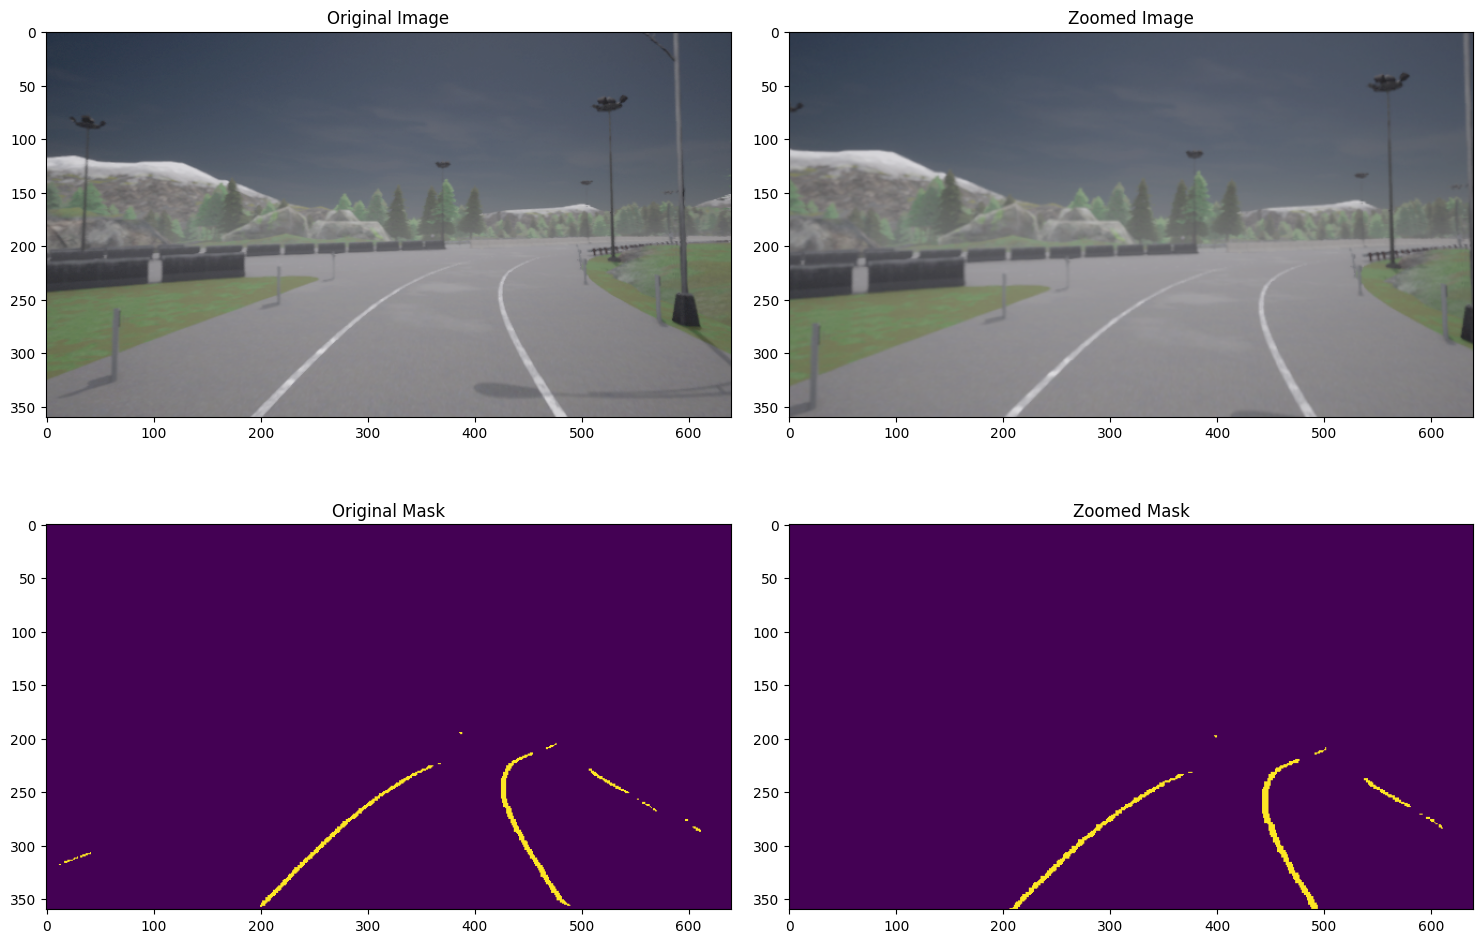

In [10]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
mask = mask_paths[random_index]

original_image = mpimg.imread(image)
original_mask = mpimg.imread(mask)

zoomed_image, zoomed_mask = zoom(original_image, original_mask)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()
axes[0][0].imshow(original_image)
axes[0][0].set_title('Original Image')
axes[0][1].imshow(zoomed_image)
axes[0][1].set_title('Zoomed Image')
axes[1][0].imshow(original_mask)
axes[1][0].set_title('Original Mask')
axes[1][1].imshow(zoomed_mask)
axes[1][1].set_title('Zoomed Mask')

In [11]:
def pan(img, mask):
    pan = A.Compose(
        [A.Affine(translate_percent={"x" : (-0.1, 0.1), "y" : (-0.1, 0.1)})],
        additional_targets={"mask" : "mask"}
    )
    augmented = pan(image=img, mask=mask)
    return augmented["image"], augmented["mask"]

Text(0.5, 1.0, 'Panned Mask')

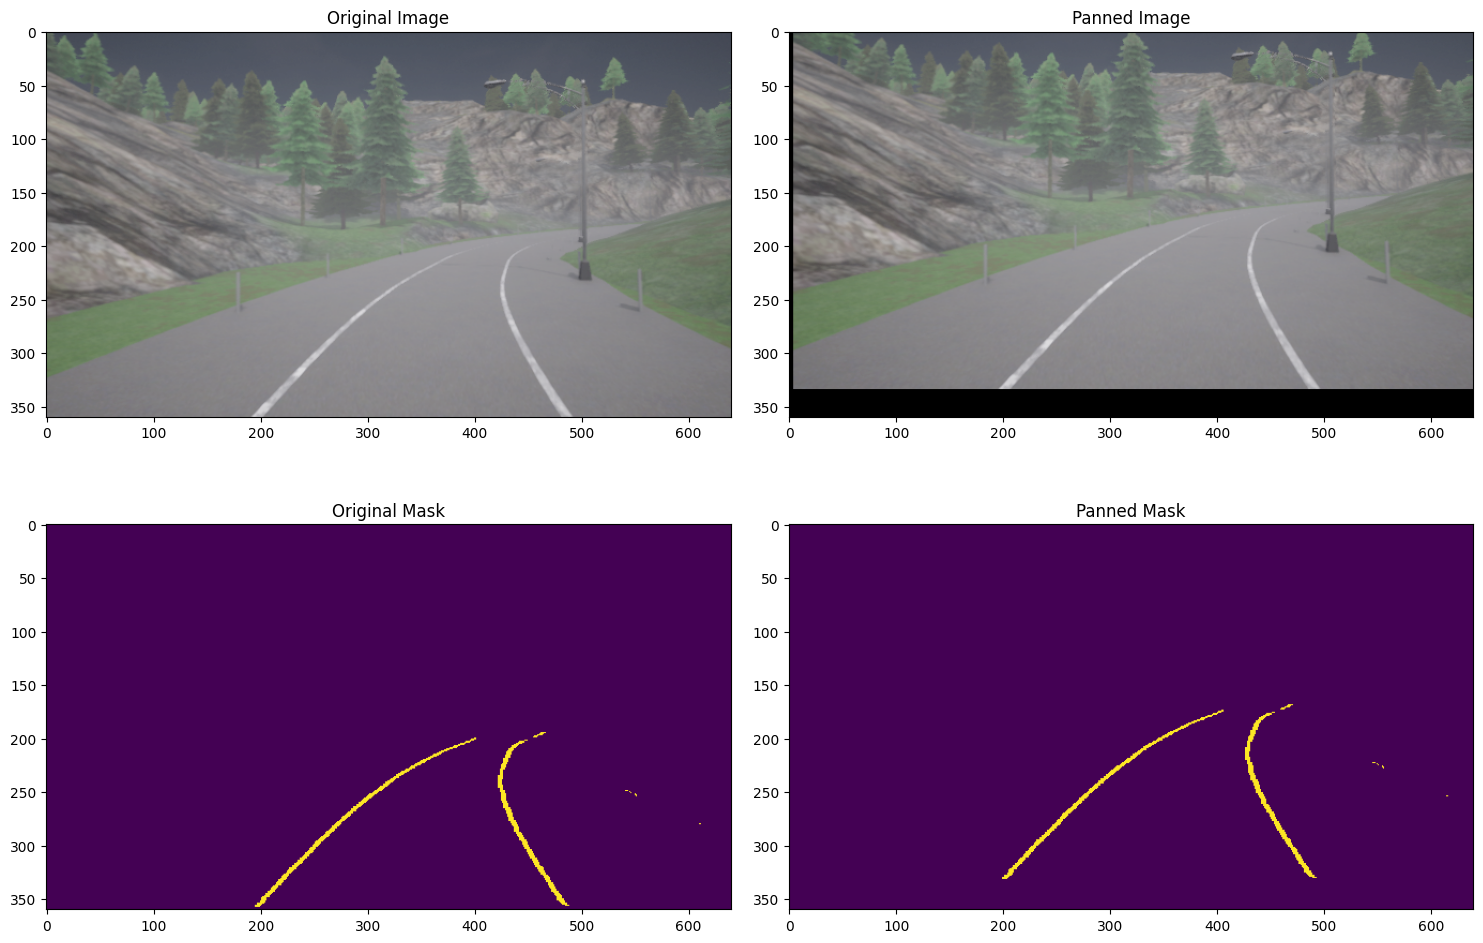

In [12]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
mask = mask_paths[random_index]

original_image = mpimg.imread(image)
original_mask = mpimg.imread(mask)

panned_image, panned_mask = pan(original_image, original_mask)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()
axes[0][0].imshow(original_image)
axes[0][0].set_title('Original Image')
axes[0][1].imshow(panned_image)
axes[0][1].set_title('Panned Image')
axes[1][0].imshow(original_mask)
axes[1][0].set_title('Original Mask')
axes[1][1].imshow(panned_mask)
axes[1][1].set_title('Panned Mask')

In [13]:
def img_random_brightness(img):
    brightness = A.RandomBrightnessContrast(
    brightness_limit=0.2,
    contrast_limit=0.0,
    p=1.0)

    augmented = brightness(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Brightness Altered Image')

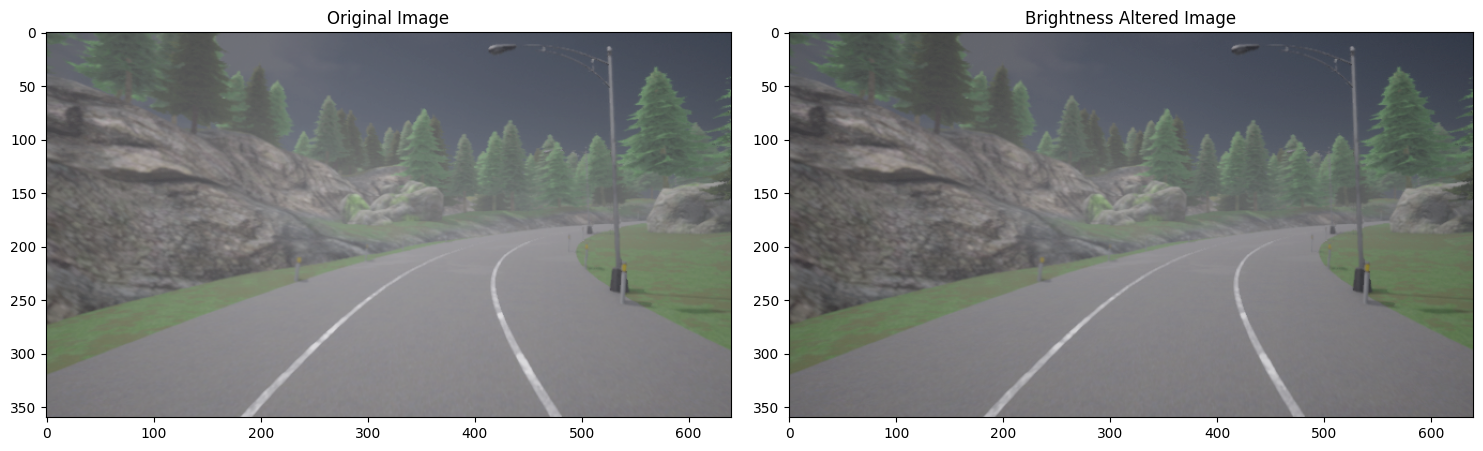

In [14]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)
brightness_altered_img = img_random_brightness(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(brightness_altered_img)
axes[1].set_title('Brightness Altered Image')

In [15]:
def img_random_flip(img, mask, steering_angle):
    img = cv2.flip(img, 1)
    mask = cv2.flip(mask, 1)
    steering_angle = -steering_angle
    return img, mask, steering_angle

Text(0.5, 1.0, 'Flipped Mask')

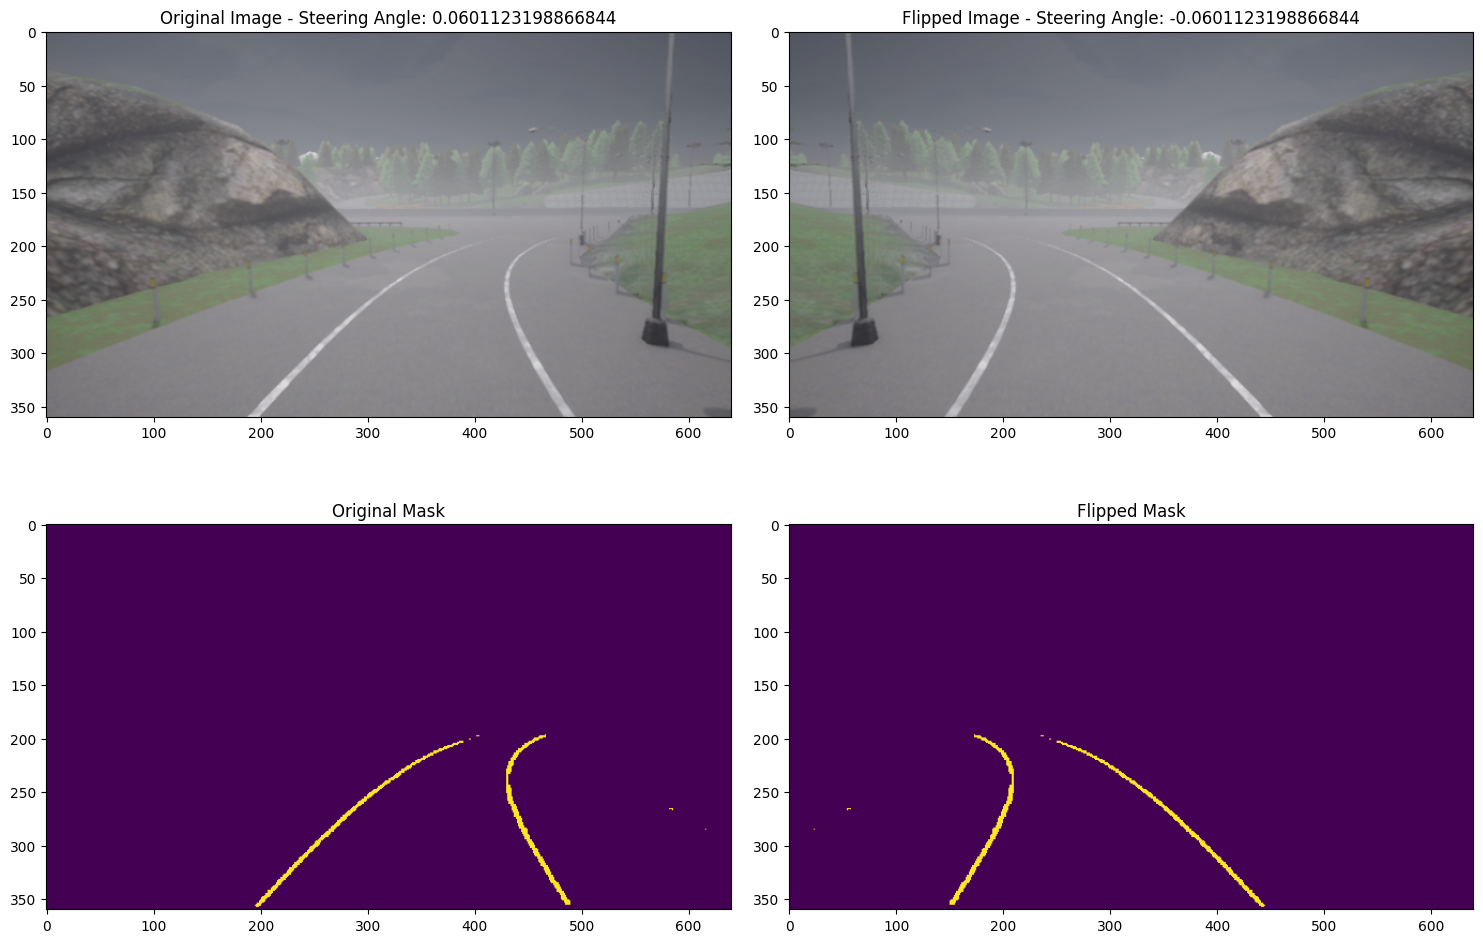

In [16]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
mask = mask_paths[random_index]
steering_angle = steerings[random_index]

original_image = mpimg.imread(image)
original_mask = mpimg.imread(mask)

flipped_image, flipped_mask, flipped_steering = img_random_flip(original_image, original_mask, steering_angle)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()
axes[0][0].imshow(original_image)
axes[0][0].set_title('Original Image - Steering Angle: ' + str(steering_angle))
axes[0][1].imshow(flipped_image)
axes[0][1].set_title('Flipped Image - Steering Angle: ' + str(flipped_steering))
axes[1][0].imshow(original_mask)
axes[1][0].set_title('Original Mask')
axes[1][1].imshow(flipped_mask)
axes[1][1].set_title('Flipped Mask')

In [17]:
def random_augment(image, mask, steering_angle):
    image = mpimg.imread(image)
    mask = mpimg.imread(mask)

    if np.random.rand() < 0.5:
        image, mask = pan(image, mask)

    if np.random.rand() < 0.5:
        image, mask = zoom(image, mask)
    
    if np.random.rand() < 0.5:
        image = img_random_brightness(image)
    
    if np.random.rand() < 0.5:
        image, mask, steering_angle = img_random_flip(image, mask, steering_angle)
    
    return image, mask, steering_angle

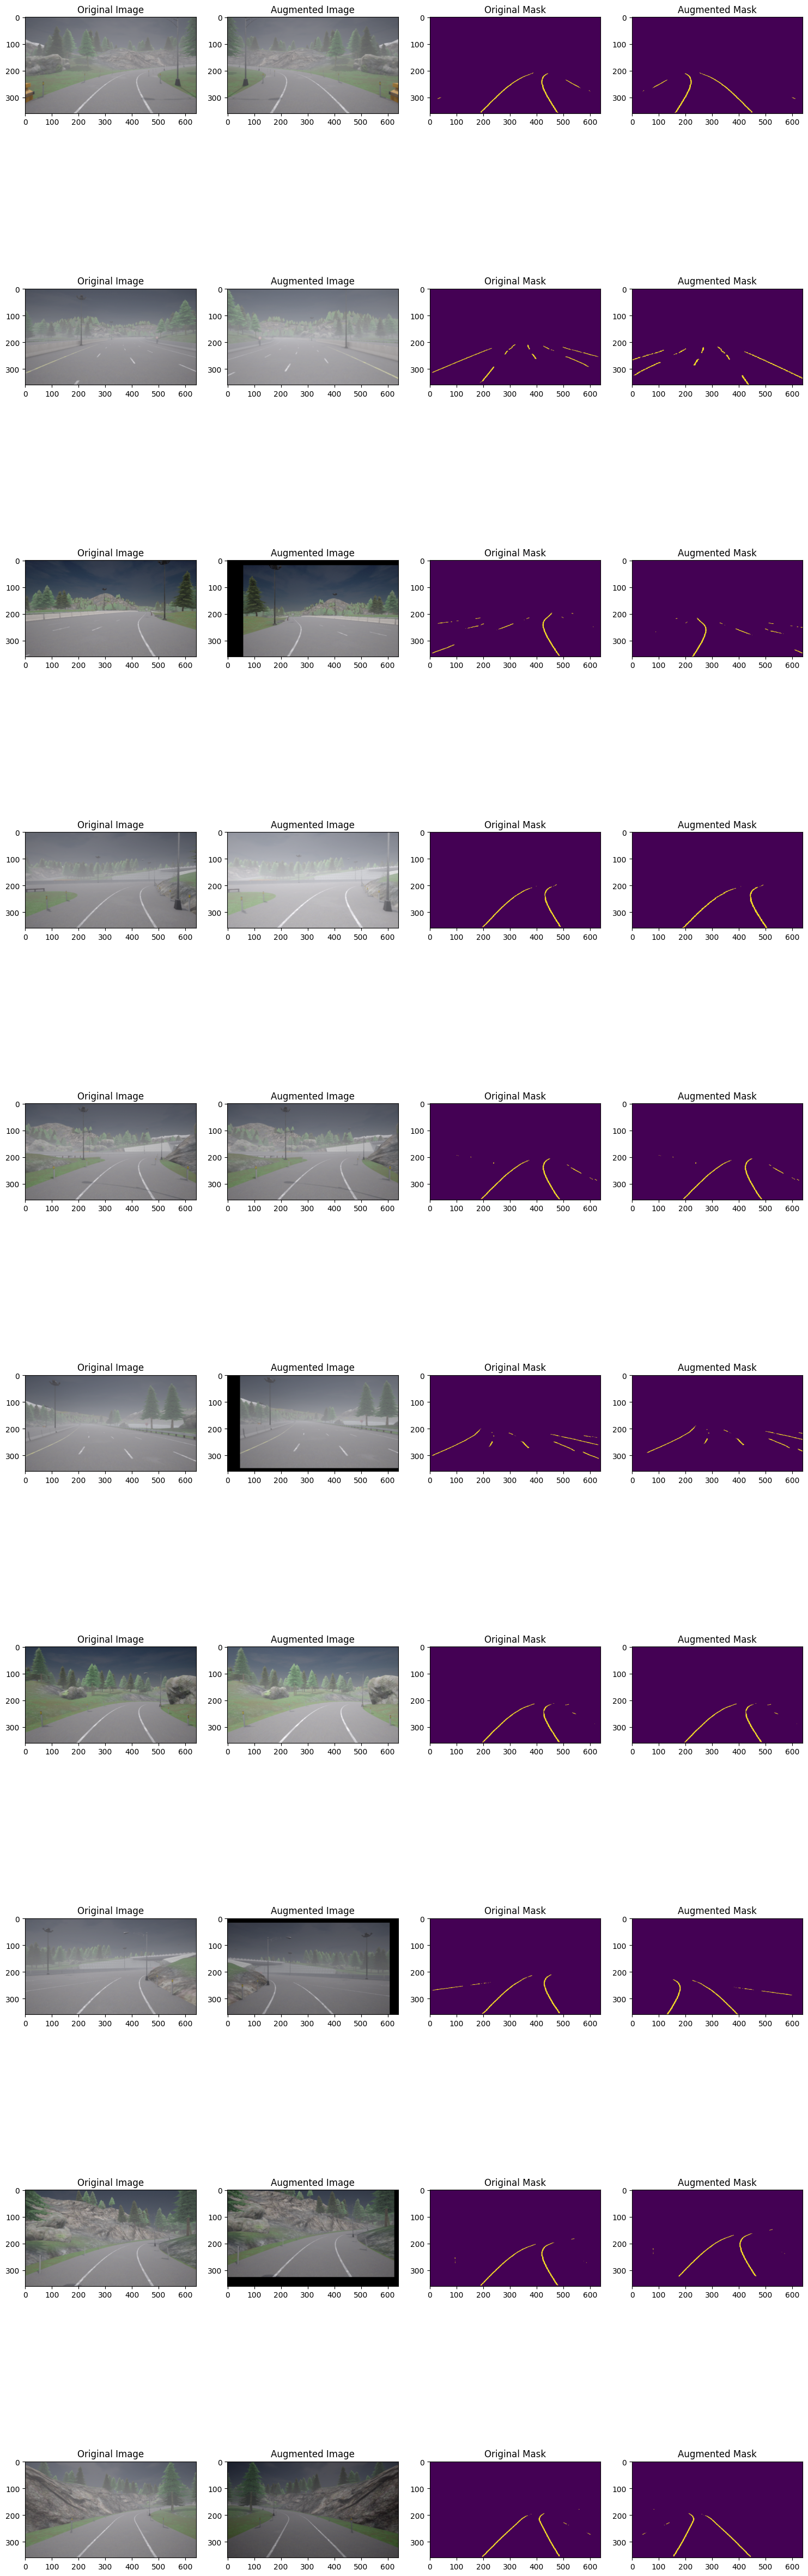

In [18]:
ncol = 4
nrow = 10

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 50))
fig.tight_layout()

for i in range(10):
    randnum = random.randint(0, len(rgb_paths) - 1)
    random_image = rgb_paths[randnum]
    random_mask = mask_paths[randnum]
    random_steering = steerings[randnum]

    original_image = mpimg.imread(random_image)
    original_mask = mpimg.imread(random_mask)

    augmented_image, augmented_mask, augmented_steering = random_augment(random_image, random_mask, random_steering)

    axes[i][0].imshow(original_image)
    axes[i][0].set_title('Original Image')
    axes[i][1].imshow(augmented_image)
    axes[i][1].set_title('Augmented Image')
    axes[i][2].imshow(original_mask)
    axes[i][2].set_title('Original Mask')
    axes[i][3].imshow(augmented_mask)
    axes[i][3].set_title('Augmented Mask')

In [19]:
def img_mask_preprocess(img, mask):
    img = img[200:, :, :]
    img = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.resize(img, (200, 66))
    img = img.astype(np.float32) / 255.0

    mask = mask[200:, :]
    mask = cv2.resize(mask, (200, 66), interpolation=cv2.INTER_NEAREST)

    return img, mask

Text(0.5, 1.0, 'Preprocessed Mask')

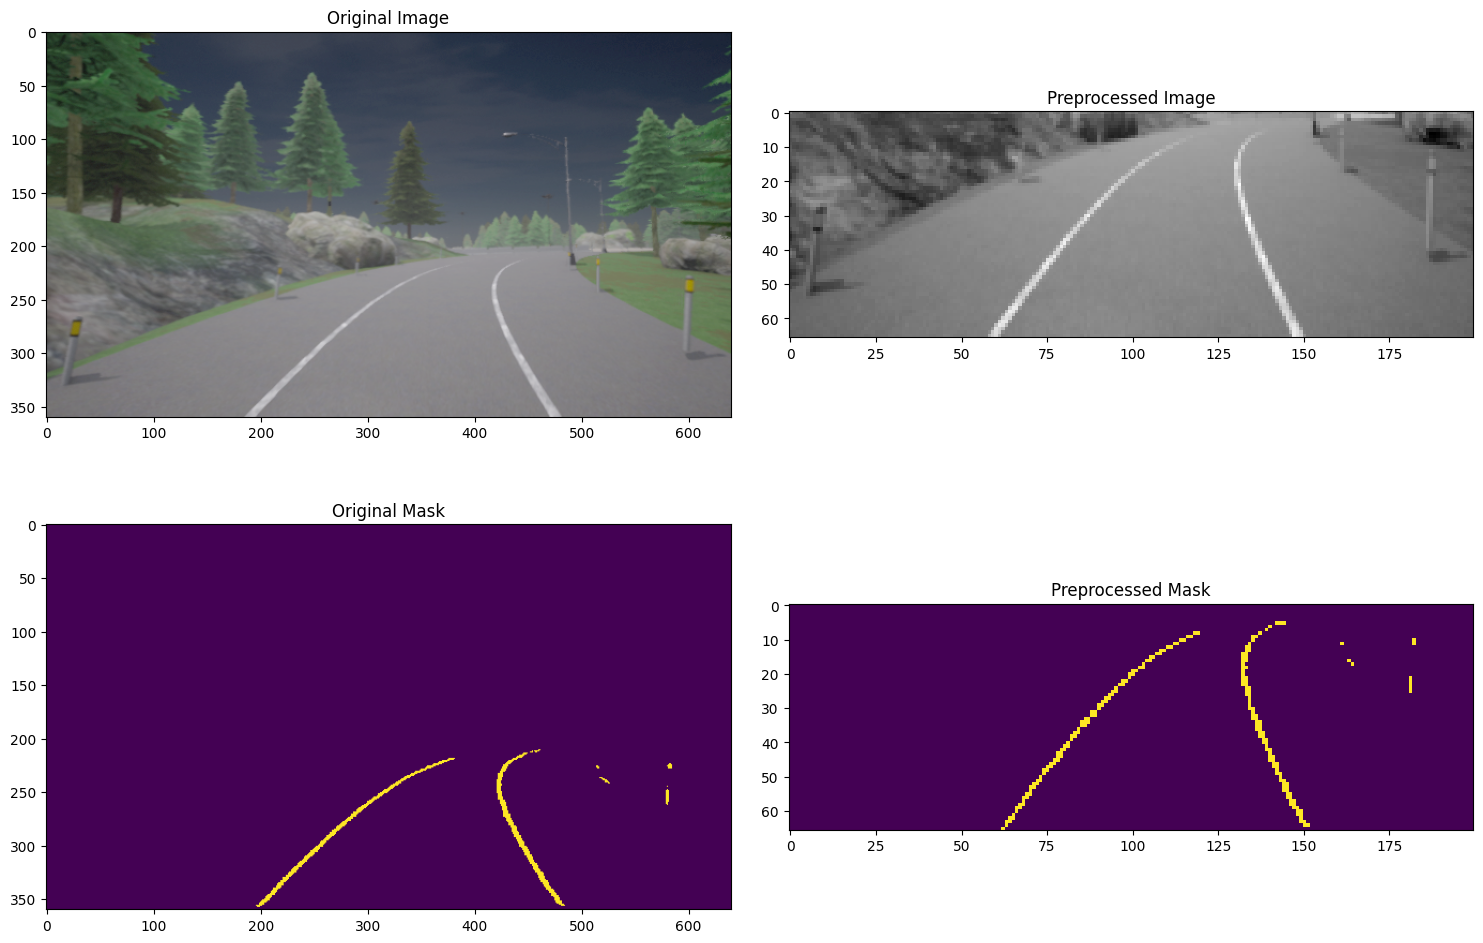

In [20]:
image = rgb_paths[100]
mask = mask_paths[100]
original_image = mpimg.imread(image)
original_mask = mpimg.imread(mask)
preprocessed_image, preprocessed_mask = img_mask_preprocess(original_image, original_mask)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()
axes[0][0].imshow(original_image)
axes[0][0].set_title('Original Image')
axes[0][1].imshow(preprocessed_image[:, :, 0], cmap='gray')
axes[0][1].set_title('Preprocessed Image')

axes[1][0].imshow(original_mask)
axes[1][0].set_title('Original Mask')
axes[1][1].imshow(preprocessed_mask)
axes[1][1].set_title('Preprocessed Mask')

In [21]:
def batch_generator(image_paths, mask_paths, steering_angles, batch_size, istraining):
    while True:
        batch_img = []
        batch_mask = []
        batch_steering = []

        for i in range(batch_size):
            random_index = random.randint(0, len(image_paths) - 1)

            if istraining:
                img, mask, steering = random_augment(image_paths[random_index], mask_paths[random_index], steering_angles[random_index])
            else:
                img = mpimg.imread(image_paths[random_index])
                mask = mpimg.imread(mask_paths[random_index])
                steering = steering_angles[random_index]

            img, mask = img_mask_preprocess(img, mask)
            batch_img.append(img)
            batch_mask.append(mask)
            batch_steering.append(steering)
        
        batch_img = np.array(batch_img, dtype=np.float32)
        batch_mask = np.array(batch_mask, dtype=np.float32)
        batch_steering = np.array(batch_steering, dtype=np.float32)
        yield ([np.asarray(batch_img), np.asarray(batch_mask)], np.asarray(batch_steering))

Text(0.5, 1.0, 'Validation Mask')

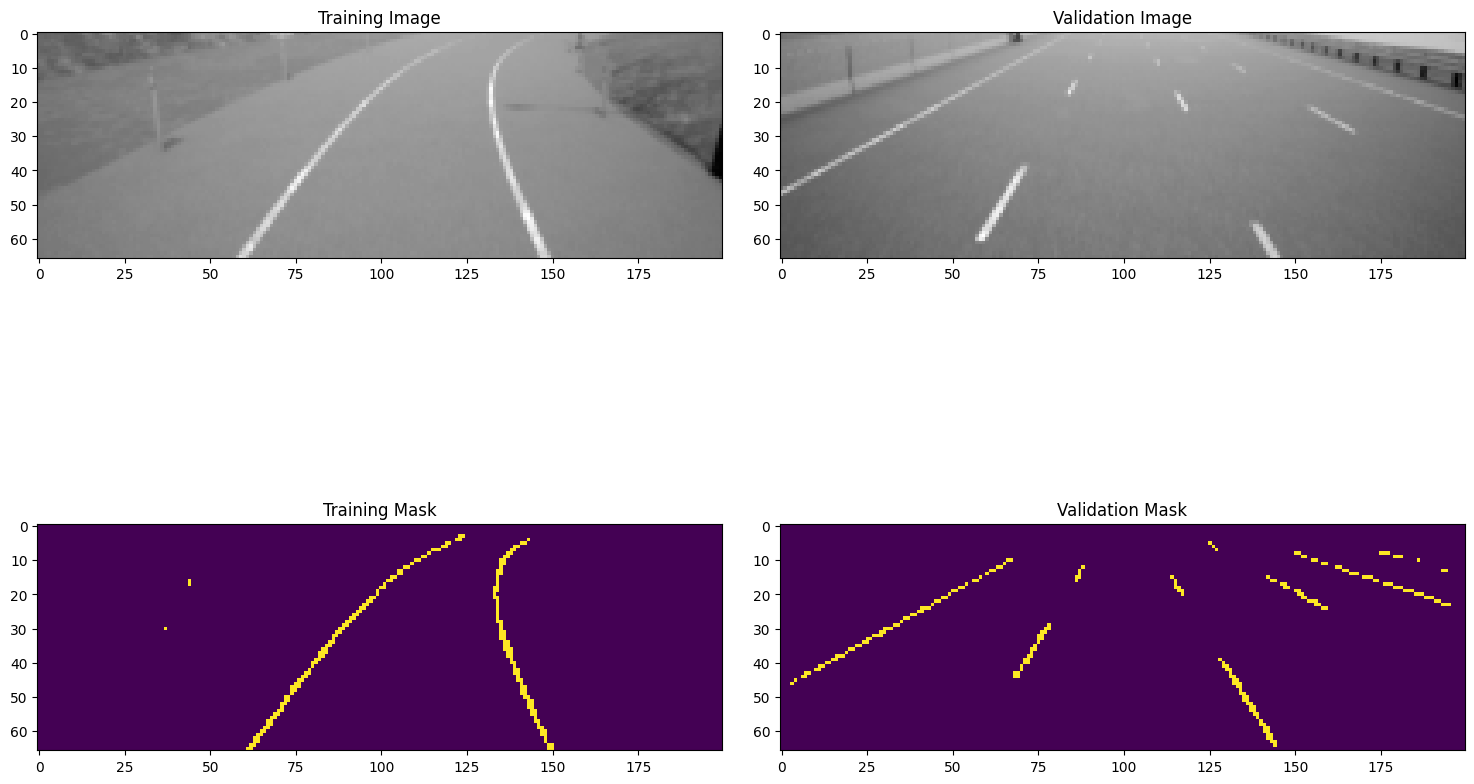

In [22]:
train_gen, steer_train_gen = next(batch_generator(rgb_train, mask_train, steer_train, 1, 1))
valid_gen, steer_valid_gen = next(batch_generator(rgb_valid, mask_valid, steer_valid, 1, 0))

rgb_train_gen, mask_train_gen = train_gen[0], train_gen[1]
rgb_valid_gen, mask_valid_gen = valid_gen[0], valid_gen[1]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout()

axes[0][0].imshow(rgb_train_gen[0][:, :, 0], cmap='gray')
axes[0][0].set_title('Training Image')
axes[0][1].imshow(rgb_valid_gen[0][:, :, 0], cmap='gray')
axes[0][1].set_title('Validation Image')

axes[1][0].imshow(mask_train_gen[0])
axes[1][0].set_title('Training Mask')
axes[1][1].imshow(mask_valid_gen[0])
axes[1][1].set_title('Validation Mask')

In [23]:
def steering_model():
  img_input = Input(shape=(66, 200, 3), name="img_input")
  mask_input = Input(shape=(66, 200, 1), name="mask_input")

  x1 = Convolution2D(24, (5,5), strides=(2,2), activation='elu')(img_input)
  x1 = Convolution2D(36, (5,5), strides=(2,2), activation='elu')(x1)
  x1 = Convolution2D(64, (3,3), activation='elu')(x1)
  x1 = Convolution2D(64, (3,3), activation='elu')(x1)
  x1 = Flatten()(x1)

  x2 = Convolution2D(24, (5, 5), strides=(2,2), activation='elu')(mask_input)
  x2 = Convolution2D(36, (5, 5), strides=(2,2), activation='elu')(x2)
  x2 = Convolution2D(64, (3,3), activation='elu')(x2)
  x2 = Convolution2D(64, (3,3), activation='elu')(x2)
  x2 = Flatten()(x2)

  x = concatenate([x1, x2])
  x = Dense(100, activation='elu')(x)
  x = Dense(50, activation='elu')(x)
  x = Dense(10, activation='elu')(x)

  output = Dense(1, name="steering_output")(x)

  model = Model(inputs=[img_input, mask_input], outputs=output)
  optimizer = Adam(learning_rate=1e-3)
  model.compile(loss='mse', optimizer=optimizer)

  return model

In [24]:
model = steering_model()
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 66, 200,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_input          │ (None, 66, 200,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 31, 98,    │      1,824 │ img_input[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 31, 98,    │        624 │ mask_input[0][0]  │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 47,    │     21,636 │ conv2d[0][0]      │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 47,    │     21,636 │ conv2d_4[0][0]    │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 45,    │     20,800 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 12, 45,    │     20,800 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 10, 43,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 10, 43,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 27520)     │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 27520)     │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 55040)     │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100)       │  5,504,100 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      5,050 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │        510 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ steering_output     │ (None, 1)         │         11 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,670,847 (21.63 MB)

 Trainable params: 5,670,847 (21.63 MB)

 Non-trainable params: 0 (0.00 B)

None


In [25]:
history = model.fit(batch_generator(rgb_train, mask_train, steer_train, batch_size=100, istraining=1), steps_per_epoch=300, epochs=10, validation_data=(batch_generator(rgb_valid, mask_valid, steer_valid, batch_size=100, istraining=0)), validation_steps=200, verbose=1, shuffle=1)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - loss: 0.0405 - val_loss: 6.7480e-04
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - loss: 0.0016 - val_loss: 7.2464e-04
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - loss: 0.0015 - val_loss: 8.4374e-04
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - loss: 0.0014 - val_loss: 6.5935e-04
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - loss: 0.0012 - val_loss: 6.2873e-04
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - loss: 9.9654e-04 - val_loss: 5.6435e-04
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - loss: 9.5113e-04 - val_loss: 5.8621e-04
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - loss: 8.1368e-04 - val_loss: 5.5233e-04
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - loss: 8.5106e-04 - val_loss: 5.6792e-04
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - loss: 7.6758e-04 - val_loss: 6.2513e-04


Text(0.5, 0, 'Epoch')

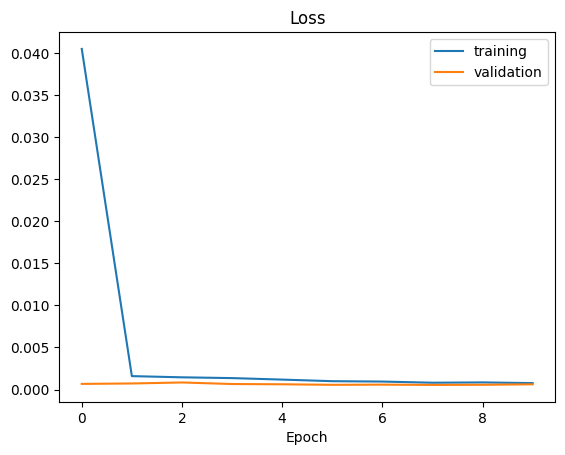

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'])
plt.title('Loss')
plt.xlabel('Epoch')

In [27]:
model.save('steering_model.h5')